# Exploration of the data and some algorithms

## Imports

In [1]:
from sklearn.linear_model import LogisticRegression
from sklearn.svm import SVC
from xgboost import XGBClassifier
import numpy as np

from service.datasetservice.DatasetService import DatasetService
from sklearn.model_selection import train_test_split
from sklearn.metrics import confusion_matrix, accuracy_score, recall_score, precision_score, f1_score, ConfusionMatrixDisplay, roc_curve, auc, RocCurveDisplay

from imblearn.over_sampling import SMOTE
from imblearn.under_sampling import RandomUnderSampler, TomekLinks

## Dataset Analysis

In [2]:
dataset_service = DatasetService()
dataset = dataset_service.load_dataset()
dataset.describe()

,Participant,HR,respr,Time(sec),Label
count,112516.000000,112472.000000,112516.000000,1.125160e+05,112516.000000
mean,18.475470,80.216177,12.465482,1.645692e+09,0.327198
std,9.871133,12.732206,2.030810,8.179419e+05,0.469192
min,2.000000,49.000000,5.204728,1.644228e+09,0.000000
25%,10.000000,71.330000,11.191843,1.644846e+09,0.000000
50%,18.000000,77.890000,12.743635,1.645461e+09,0.000000
75%,27.000000,87.020000,13.877519,1.646648e+09,1.000000
max,35.000000,146.780000,18.163532,1.646842e+09,1.000000


In [3]:
dataset.head(10)

,Participant,HR,respr,Time(sec),Label
0,2,118.00,12.127693,1644227583,0
1,2,113.50,12.127693,1644227584,0
2,2,93.00,12.127693,1644227585,0
3,2,93.25,12.127693,1644227586,0
4,2,86.40,12.127693,1644227587,0
5,2,81.83,12.127693,1644227588,0
6,2,79.71,12.127693,1644227589,0
7,2,78.12,12.127693,1644227590,0
8,2,76.67,12.127693,1644227591,0
9,2,75.60,12.127693,1644227592,0


### Class balances

<Axes: ylabel='Label'>

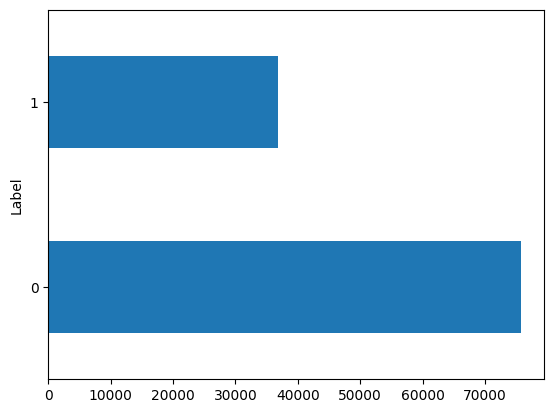

In [4]:
dataset["Label"].value_counts().plot(kind="barh")

## Data Preparation

### Drop NaN

In [5]:
dataset = dataset_service.remove_nan(dataset=dataset)
dataset.describe()

,Participant,HR,respr,Time(sec),Label
count,112472.000000,112472.000000,112472.000000,1.124720e+05,112472.000000
mean,18.475923,80.216177,12.465400,1.645692e+09,0.327326
std,9.871188,12.732206,2.030968,8.179379e+05,0.469239
min,2.000000,49.000000,5.204728,1.644228e+09,0.000000
25%,10.000000,71.330000,11.191836,1.644846e+09,0.000000
50%,18.000000,77.890000,12.743508,1.645461e+09,0.000000
75%,27.000000,87.020000,13.877583,1.646648e+09,1.000000
max,35.000000,146.780000,18.163532,1.646842e+09,1.000000


### Get train and test data

In [23]:
x, y, labels = dataset_service.get_features_and_labels(dataset=dataset)

#### Oversampling minority class

In [24]:
x_resampled, y_resampled = SMOTE().fit_resample(X=x, y=y)

print("Before oversampling")
print("No Stress: ", np.count_nonzero(y==0))
print("Stress: ", np.count_nonzero(y==1))
print("\nAfter oversampling")
print("No Stress: ", np.count_nonzero(y_resampled==0))
print("Stress: ", np.count_nonzero(y_resampled==0))

Before oversampling
No Stress:  75657
Stress:  36815

After oversampling
No Stress:  75657
Stress:  75657


In [25]:
# Shuffle to remove time construct
train_x, test_x, train_y, test_y = train_test_split(x_resampled, y_resampled, test_size=0.2, shuffle=True, random_state=42)

## Model

In [26]:
from sklearn.model_selection import StratifiedKFold, GridSearchCV

# model = LogisticRegression(random_state=42).fit(X=train_x, y=train_y)
# model = XGBClassifier(n_estimators=50, max_depth=50, learning_rate=1, objective='binary:logistic', random_state=42).fit(X=train_x, y=train_y)
# grid search
model = XGBClassifier()
n_estimators = [50, 100, 150, 200]
max_depth = [2, 4, 6, 8]
print(max_depth)
param_grid = dict(max_depth=max_depth, n_estimators=n_estimators)
kfold = StratifiedKFold(n_splits=10, shuffle=True, random_state=7)
grid_search = GridSearchCV(model, param_grid, scoring="neg_log_loss", n_jobs=-1, cv=kfold, verbose=1)
grid_result = grid_search.fit(train_x, train_y)
# summarize results
print("Best: %f using %s" % (grid_result.best_score_, grid_result.best_params_))
means = grid_result.cv_results_['mean_test_score']
stds = grid_result.cv_results_['std_test_score']
params = grid_result.cv_results_['params']
for mean, stdev, param in zip(means, stds, params):
    print("%f (%f) with: %r" % (mean, stdev, param))

[2, 4, 6, 8]
Fitting 10 folds for each of 16 candidates, totalling 160 fits
Best: -0.527218 using {'max_depth': 8, 'n_estimators': 200}
-0.649748 (0.001681) with: {'max_depth': 2, 'n_estimators': 50}
-0.642012 (0.002070) with: {'max_depth': 2, 'n_estimators': 100}
-0.637444 (0.001920) with: {'max_depth': 2, 'n_estimators': 150}
-0.633734 (0.002148) with: {'max_depth': 2, 'n_estimators': 200}
-0.621694 (0.003072) with: {'max_depth': 4, 'n_estimators': 50}
-0.604045 (0.003261) with: {'max_depth': 4, 'n_estimators': 100}
-0.593991 (0.003145) with: {'max_depth': 4, 'n_estimators': 150}
-0.586860 (0.003520) with: {'max_depth': 4, 'n_estimators': 200}
-0.588226 (0.003241) with: {'max_depth': 6, 'n_estimators': 50}
-0.567387 (0.003405) with: {'max_depth': 6, 'n_estimators': 100}
-0.555934 (0.003495) with: {'max_depth': 6, 'n_estimators': 150}
-0.547829 (0.003901) with: {'max_depth': 6, 'n_estimators': 200}
-0.558667 (0.003277) with: {'max_depth': 8, 'n_estimators': 50}
-0.540898 (0.003715) wi

In [27]:
pred = grid_result.best_estimator_.predict(X=test_x)

### Scores

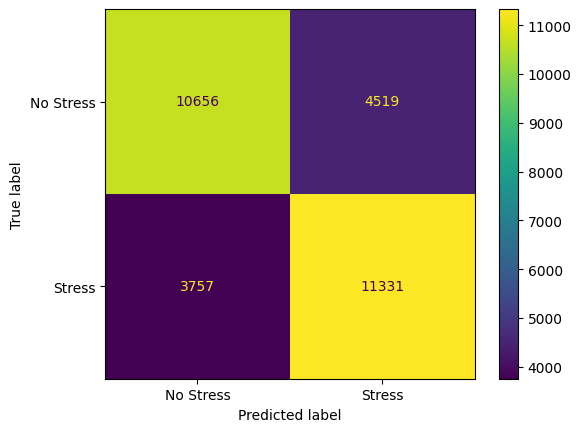

In [28]:
cm = confusion_matrix(y_true=test_y, y_pred=pred)
acc = accuracy_score(pred, test_y)
rec = recall_score(pred, test_y)
prec = precision_score(pred, test_y)
f1 = f1_score(pred, test_y)
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=labels)
disp.plot()

In [29]:
print("Accuracy: ", acc)
print("Recall: ", rec)
print("Precision: ", prec)
print("F1 Score: ", f1)

Accuracy:  0.7265307471169414
Recall:  0.7148895899053628
Precision:  0.7509941675503712
F1 Score:  0.7324972525696555


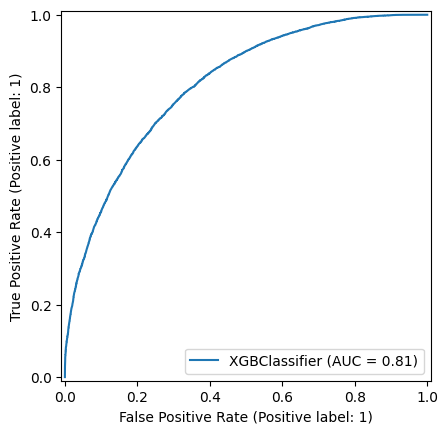

In [30]:
disp = RocCurveDisplay.from_estimator(estimator=grid_result.best_estimator_, X=test_x, y=test_y)